# <center><strong>Fracture multi region x-ray</strong></center>
-------------------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------------------------------------------------

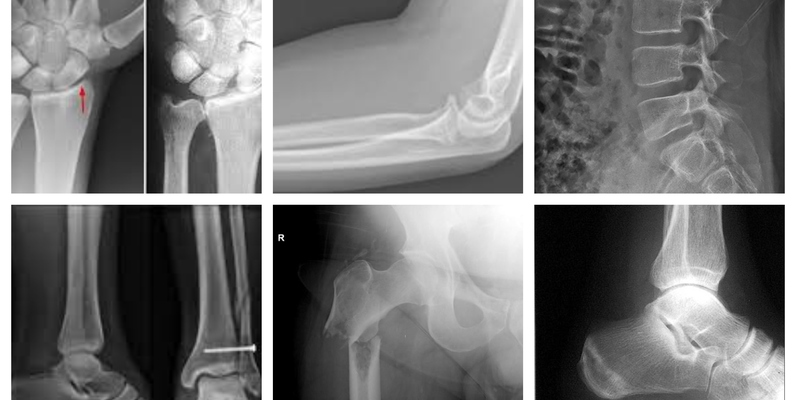

In [1]:
from IPython.display import Image
Image(filename='cover.jpg') 

--------------------------
--------------------------

# <center><strong>About Dataset</strong></center>
------------------------
#### **This dataset comprises fractured and non-fractured X-ray images covering all anatomical body regions, including lower limb, upper limb, lumbar, hips, knees, etc. The dataset is categorized into train, test, and validation folders, each containing fractured and non-fractured radiographic images. Click this link https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/data to access the dataset.**

--------------------------------
--------------------------------
## **Import Libraries**

In [ ]:
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from sklearn.utils import shuffle           
import tensorflow as tf
import keras

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model 
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from tqdm import tqdm
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

2026-02-08 13:33:49.958094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770557630.166209      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770557630.222750      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770557630.697079      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770557630.697132      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770557630.697136      56 computation_placer.cc:177] computation placer alr

---------------------------------------
---------------------------------------

In [4]:
train_fractured = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/fractured'
train_not_fractured = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured'

In [5]:
print(train_fractured.split('/')[7],' : ', len(os.listdir(train_fractured)))
print(train_not_fractured.split('/')[7],' : ', len(os.listdir(train_not_fractured)))

fractured  :  4606
not fractured  :  4640


In [6]:
train_df = []
train_df.append(train_fractured)
train_df.append(train_not_fractured)

In [7]:
train_df

['/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/fractured',
 '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured']

-----------------------------

In [8]:
test_fractured = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured'
test_not_fractured = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured'

In [9]:
print(test_fractured.split('/')[7],' : ', len(os.listdir(test_fractured)))
print(test_not_fractured.split('/')[7],' : ', len(os.listdir(test_not_fractured)))

fractured  :  238
not fractured  :  268


In [10]:
test_df = []
test_df.append(test_fractured)
test_df.append(test_not_fractured)

In [11]:
test_df

['/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured',
 '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured']

----------------------------------

In [12]:
val_fractured = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/fractured'
val_not_fractured = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/not fractured'

In [13]:
print(val_fractured.split('/')[7],' : ', len(os.listdir(val_fractured)))
print(val_not_fractured.split('/')[7],' : ', len(os.listdir(val_not_fractured)))

fractured  :  337
not fractured  :  492


In [14]:
val_df = []
val_df.append(val_fractured)
val_df.append(val_not_fractured)

In [15]:
val_df

['/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/fractured',
 '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/not fractured']

----------------------
#### **Image array and dimension**
----------------------

In [16]:
def img_array_and_dim(fold):
    x = 0
    for img in os.listdir(fold):
        x+=1
        img_array = cv2.imread(os.path.join(fold,img))
        print('Dimension : ',img_array.shape)
        print('-------------------')
        print(img_array)
        if x == 1:
            break

In [ ]:
img_array_and_dim(train_df[0])

Dimension :  (224, 224, 3)
-------------------
[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


In [ ]:
img_array_and_dim(train_df[1])

Dimension :  (224, 224, 3)
-------------------
[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


------------------------
### **Show images**
------------------------

In [19]:
def show_img(folder):
    images = [cv2.imread(os.path.join(folder, img)) for img in os.listdir(folder)]
    fig = plt.figure(figsize=(14, 6))
    x = 0 
    for i in range(len(images)):
        x+=1
        plt.subplot(2,3,i+1)
        plt.imshow(images[i])
        plt.axis('off')
        plt.title(f'Image {i+1}') 
        if x == 6:
            break

libpng warning: bKGD: invalid
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


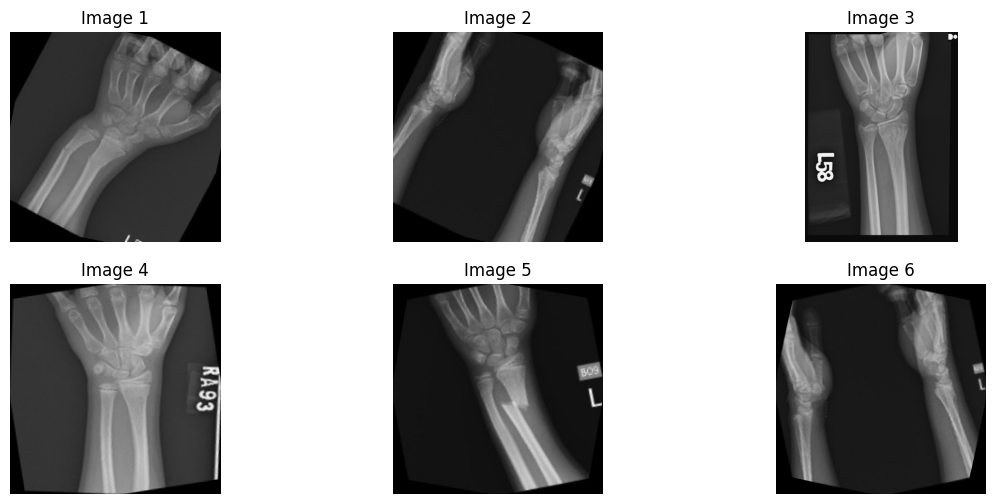

In [20]:
show_img(train_df[0])

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


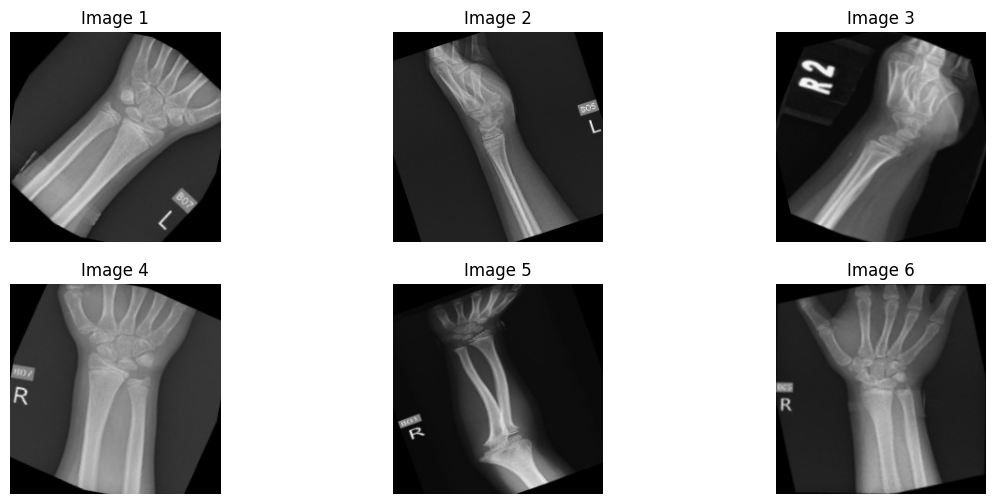

In [21]:
show_img(train_df[1])

--------------------------------
### **Checking sizes of images**
--------------------------------

In [22]:
def checking_size(folder):
    AllSizes = [(cv2.imread(os.path.join(folder, img))).shape for img in os.listdir(folder)]
    print(set(AllSizes))

In [23]:
checking_size(train_df[0])

libpng warning: bKGD: invalid
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


{(726, 426, 3), (835, 495, 3), (923, 768, 3), (442, 442, 3), (1644, 2902, 3), (320, 175, 3), (996, 866, 3), (216, 234, 3), (370, 372, 3), (335, 299, 3), (1024, 896, 3), (418, 226, 3), (562, 575, 3), (450, 170, 3), (1890, 1602, 3), (1706, 1476, 3), (327, 377, 3), (652, 492, 3), (404, 198, 3), (218, 231, 3), (731, 1024, 3), (514, 327, 3), (728, 657, 3), (1024, 820, 3), (1024, 665, 3), (746, 422, 3), (1024, 588, 3), (296, 226, 3), (751, 396, 3), (728, 1296, 3), (955, 751, 3), (2000, 1500, 3), (1706, 1586, 3), (920, 1024, 3), (751, 347, 3), (836, 515, 3), (270, 300, 3), (682, 500, 3), (291, 380, 3), (812, 525, 3), (1071, 723, 3), (1500, 946, 3), (442, 282, 3), (1350, 1666, 3), (1308, 1024, 3), (746, 540, 3), (157, 220, 3), (1024, 667, 3), (585, 480, 3), (1558, 1500, 3), (1092, 1568, 3), (656, 496, 3), (442, 301, 3), (865, 555, 3), (769, 568, 3), (600, 506, 3), (540, 383, 3), (839, 1024, 3), (734, 484, 3), (1024, 697, 3), (1024, 591, 3), (1024, 602, 3), (500, 305, 3), (380, 227, 3), (997, 9

In [24]:
checking_size(train_df[1])

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


{(1600, 858, 3), (2970, 2460, 3), (1760, 2140, 3), (1252, 998, 3), (1713, 1213, 3), (1668, 1223, 3), (2018, 1500, 3), (2504, 1730, 3), (1693, 1353, 3), (373, 454, 3), (2504, 1996, 3), (1256, 750, 3), (1491, 1201, 3), (1652, 1177, 3), (1648, 1178, 3), (1490, 1199, 3), (2024, 758, 3), (3764, 1776, 3), (1602, 1500, 3), (1878, 878, 3), (1672, 1530, 3), (1432, 758, 3), (1996, 1614, 3), (454, 373, 3), (1652, 1066, 3), (2086, 1500, 3), (1068, 1014, 3), (1353, 846, 3), (2920, 2320, 3), (1206, 1086, 3), (1252, 792, 3), (1996, 1500, 3), (1066, 548, 3), (2021, 2021, 3), (3372, 1500, 3), (1669, 799, 3), (1468, 802, 3), (1648, 1782, 3), (1115, 818, 3), (1872, 1500, 3), (2140, 1760, 3), (2044, 1500, 3), (1920, 1500, 3), (224, 224, 3), (1361, 1278, 3), (2880, 2304, 3), (1168, 938, 3)}


-------------------------
### **Resizing & Masking images**
-------------------------

In [25]:
img_size = 400
def show_img_equalized(folder):
    images = [cv2.imread(os.path.join(folder, img)) for img in os.listdir(folder)]
    fig = plt.figure(figsize=(14, 6))
    x = 0 
    for i in range(len(images)):
        x+=1
        plt.subplot(2,3,i+1)
        resize_img = cv2.resize(images[i], (img_size, img_size))
        img_gray = cv2.cvtColor(resize_img, cv2.COLOR_BGR2GRAY)
        #equalized = cv2.equalizeHist(img_gray)
        plt.imshow(img_gray, cmap='gray')
        plt.axis('off')
        plt.title(f'Image {i+1}') 
        if x == 6:
            break

libpng warning: bKGD: invalid
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


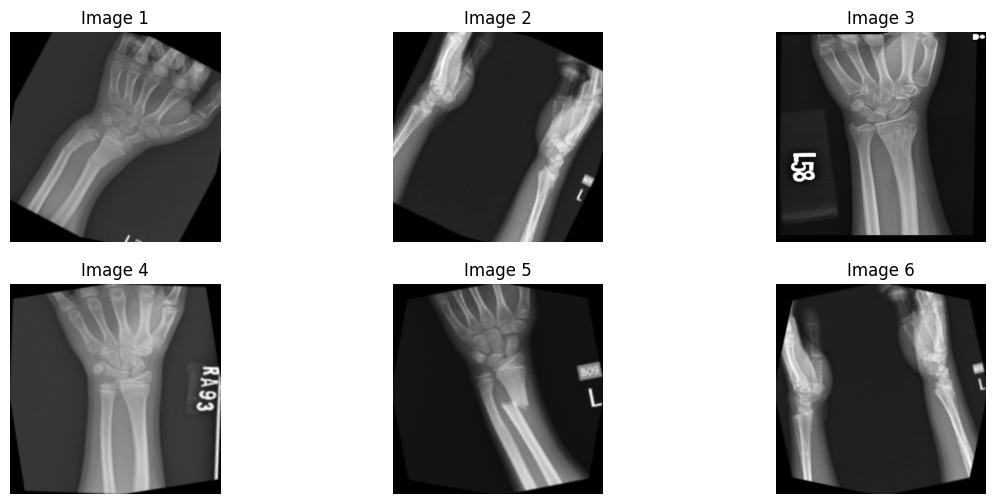

In [26]:
show_img_equalized(train_df[0])

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


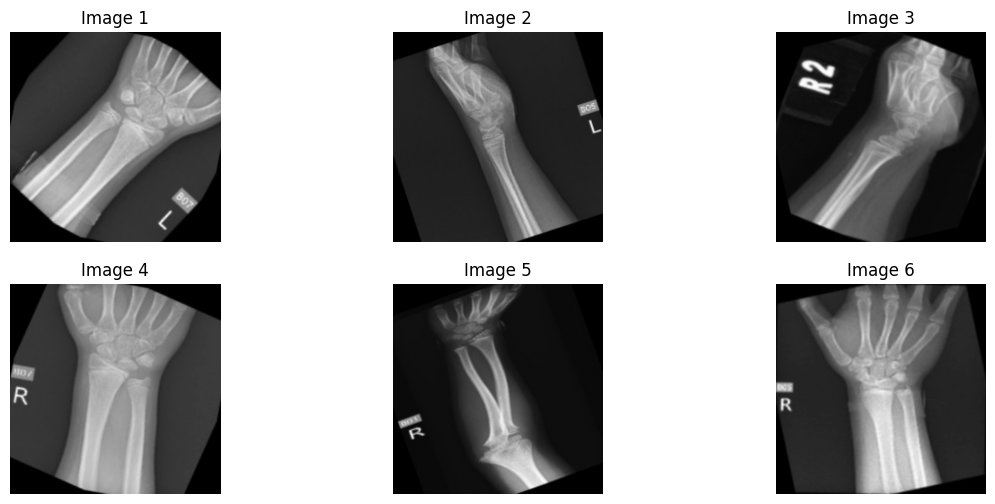

In [27]:
show_img_equalized(train_df[1])

_______________________________
### **Creating train images and labels**
-------------------------------

In [ ]:
img_size = 256
train_images = []
train_labels = []

for label, folder in enumerate(train_df):
    for img in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img)
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            continue
        resize_img = cv2.resize(img_gray, (img_size, img_size))
        resize_img = resize_img / 255.0

        train_images.append(resize_img)
        train_labels.append(label)

train_images = np.array(train_images).reshape(-1, img_size, img_size, 1)
train_labels = np.array(train_labels)

print(f"x shape: {train_images.shape}")
print(f"y shape: {train_labels.shape}")

100%|██████████| 4640/4640 [00:48<00:00, 96.29it/s] 


x shape: (9246, 256, 256, 1)
y shape: (9246,)


In [ ]:
img_size = 256
test_images = []
test_labels = []

for label, folder in enumerate(test_df):
    for img in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img)
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            continue
        resize_img = cv2.resize(img_gray, (img_size, img_size))
        resize_img = resize_img / 255.0
        
        test_images.append(resize_img)
        test_labels.append(label)

test_images = np.array(test_images).reshape(-1, img_size, img_size, 1)
test_labels = np.array(test_labels)

print(f"x shape: {test_images.shape}")
print(f"y shape: {test_labels.shape}")

  0%|          | 0/268 [00:00<?, ?it/s]Premature end of JPEG file
Premature end of JPEG file
100%|██████████| 268/268 [00:05<00:00, 49.89it/s]

x shape: (506, 256, 256, 1)
y shape: (506,)


In [ ]:
img_size = 256
val_images = []
val_labels = []

for label, folder in enumerate(val_df):
    for img in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img)
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            continue
        resize_img = cv2.resize(img_gray, (img_size, img_size))
        resize_img = resize_img / 255.0

        val_images.append(resize_img)
        val_labels.append(label)

val_images = np.array(val_images).reshape(-1, img_size, img_size, 1)
val_labels = np.array(val_labels)

print(f"x shape: {val_images.shape}")
print(f"y shape: {val_labels.shape}")

  0%|          | 0/492 [00:00<?, ?it/s]Premature end of JPEG file
Premature end of JPEG file
100%|██████████| 492/492 [00:07<00:00, 64.96it/s]


x shape: (829, 256, 256, 1)
y shape: (829,)


--------------------------------------

In [19]:
train_images[0:1]

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]]])

In [20]:
train_labels[0]

np.int64(0)

In [21]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

-------------------------
### **Building Convolutional Neural Network**
-------------------------

In [ ]:
model = keras.models.Sequential([
    
    keras.layers.Conv2D(filters=32, kernel_size=(5,5), strides=(2,2), padding='same', input_shape=(img_size, img_size, 1)),
    keras.layers.Activation('relu'),
    keras.layers.Dropout(0.5),  
    keras.layers.Conv2D(64, kernel_size=(5,5), strides=(2,2), activation='relu'),  
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'), 
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(2, activation='softmax')
])

2026-02-08 13:36:36.449911: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
optimizer = RMSprop(learning_rate=0.0005)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,872,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,933,122 (30.26 MB)

 Trainable params: 7,933,122 (30.26 MB)

 Non-trainable params: 0 (0.00 B)

-----------------------------
### **Training Model**
-----------------------------

In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='accuracy', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='accuracy', factor=0.5, patience=3)
]

In [26]:
history = model.fit(train_images, train_labels,
                    batch_size=32,
                    steps_per_epoch	= 20,
                    epochs=30,
                    validation_data=(val_images, val_labels),
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4997 - loss: 0.8331 - val_accuracy: 0.6924 - val_loss: 0.6909 - learning_rate: 5.0000e-04
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5617 - loss: 0.6793 - val_accuracy: 0.7201 - val_loss: 0.6873 - learning_rate: 5.0000e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6186 - loss: 0.6407 - val_accuracy: 0.7201 - val_loss: 0.6536 - learning_rate: 5.0000e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6508 - loss: 0.6341 - val_accuracy: 0.7033 - val_loss: 0.6265 - learning_rate: 5.0000e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6969 - loss: 0.5900 - val_accuracy: 0.6888 - val_loss: 0.6016 - learning_rate: 5.0000e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7089 - loss: 0.5552 - val_accuracy: 0.6803 - val_loss: 0.5970 - learning_rate: 5.0000e-04
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7694 - loss:

In [35]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.9628 - loss: 0.1283
Test Loss: 0.2041
Test Accuracy: 0.9289


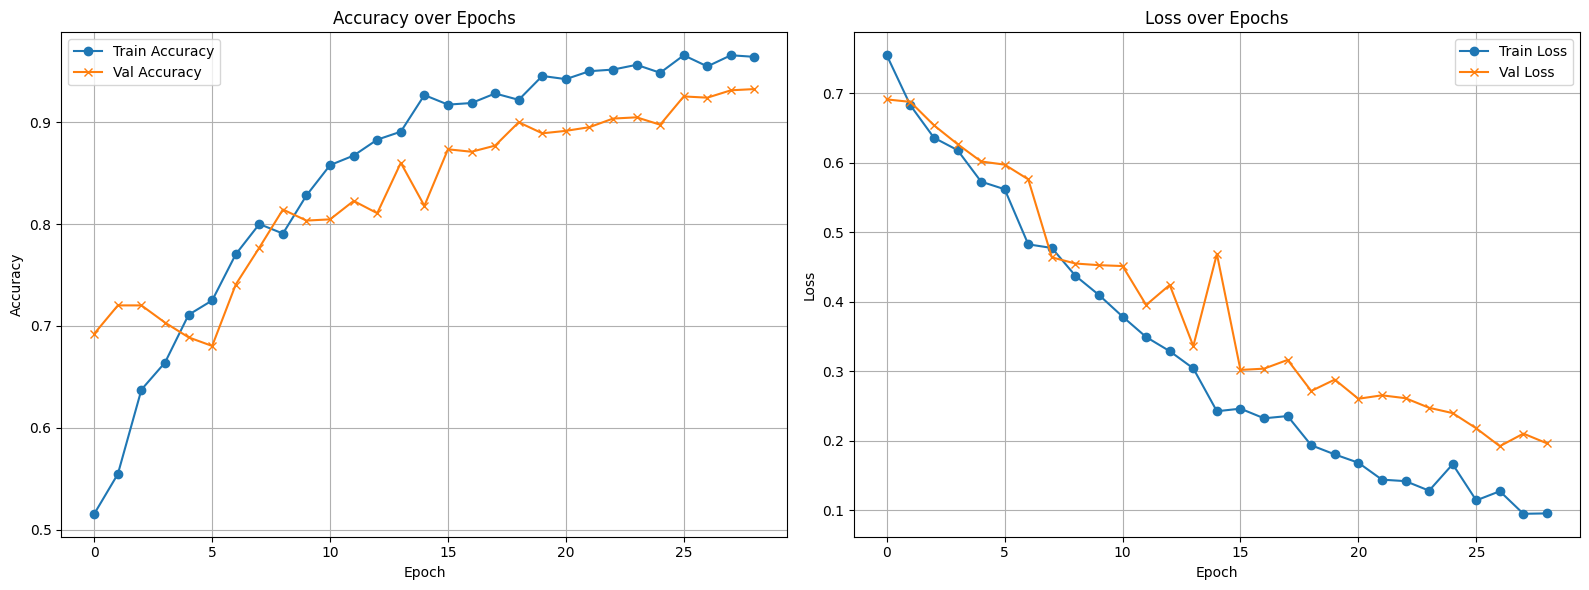

In [36]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [46]:
print(test_labels.shape)
print(test_labels[:10])

(506,)
[0 0 0 0 0 0 0 0 0 0]


In [47]:
categories = ['fractured','not fractured']
y_true = test_labels
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step


In [48]:
print(classification_report(y_true, y_pred_classes, target_names=categories))

               precision    recall  f1-score   support

    fractured       0.89      0.97      0.93       238
not fractured       0.98      0.89      0.93       268

     accuracy                           0.93       506
    macro avg       0.93      0.93      0.93       506
 weighted avg       0.93      0.93      0.93       506



<Figure size 1200x600 with 0 Axes>

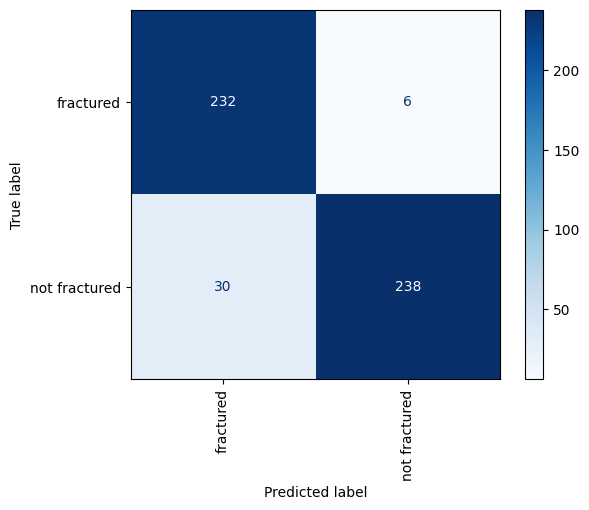

In [49]:
plt.figure(figsize = (12,6))
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.show()

In [51]:
# Loading Model
from keras.models import load_model

model.save('fracture multy region X-Ray model.h5')
print("Model saved successfully!")

Model saved successfully!


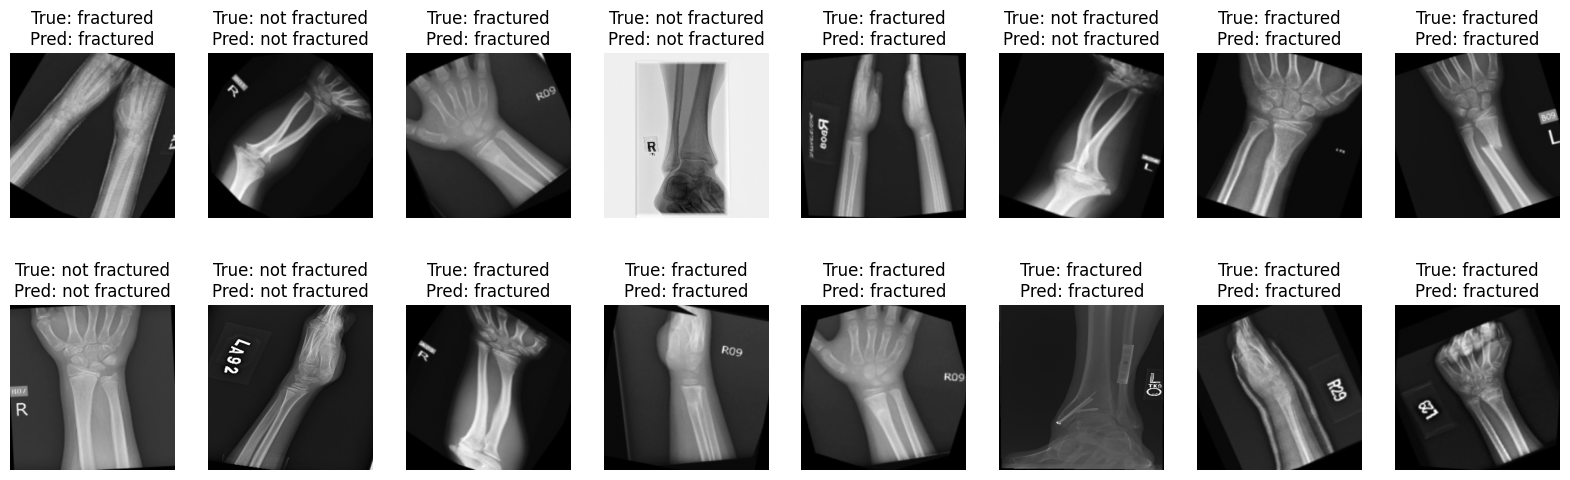

In [50]:
plt.figure(figsize=(20, 6))
for i in range(16):
    idx = np.random.randint(0, len(test_images))
    plt.subplot(2,8,i+1)
    plt.imshow(test_images[idx],cmap='gray')
    plt.title(f"True: {categories[y_true[idx]]}\nPred: {categories[y_pred_classes[idx]]}")
    plt.axis("off")
plt.show()

----------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
##### **In this project, a deep learning model based on Convolutional Neural Networks (CNNs) was developed to classify X-ray images for bone fracture detection. The workflow included careful image preprocessing, such as resizing, grayscale conversion, and contrast enhancement, followed by model training and evaluation using performance metrics suited to medical imaging tasks.**

##### **The experimental results demonstrate that the proposed model achieves strong performance, with an overall accuracy of 93% and a high sensitivity (recall) of 97% for the fractured class. This indicates the model’s effectiveness in identifying the majority of fracture cases while minimizing critical false negative errors, which is a key requirement in medical diagnosis. Such performance highlights the potential of the model as a clinical decision support tool rather than a replacement for professional medical judgment.**

##### **Despite these promising results, further improvements can be achieved by increasing dataset diversity, incorporating model interpretability techniques such as Grad-CAM, and exploring more advanced architectures or threshold optimization strategies. In conclusion, this project underscores the significant role of artificial intelligence in medical imaging and its potential to enhance diagnostic accuracy and efficiency in healthcare applications.**

---------------------------------------

In [ ]:
#!jupyter nbconvert --to html "Fracture-multi-region-x-ray classification.ipynb"

[NbConvertApp] Converting notebook Fracture-multi-region-x-ray classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 2045294 bytes to Fracture-multi-region-x-ray classification.html
